In [36]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
## 1. Load data
df = pd.read_csv("../data/raw/sandp500/all_stocks_5yr.csv")
df.head()

,date,open,high,low,close,volume,Name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL


In [38]:
## Basic inspection of data
print("Shape: ", df.shape, "\nDatatypes:\n", df.dtypes)
print("\nInfo:")
df.info()

Shape:  (619040, 7) 
Datatypes:
 date          str
open      float64
high      float64
low       float64
close     float64
volume      int64
Name          str
dtype: object

Info:
<class 'pandas.DataFrame'>
RangeIndex: 619040 entries, 0 to 619039
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    619040 non-null  str    
 1   open    619029 non-null  float64
 2   high    619032 non-null  float64
 3   low     619032 non-null  float64
 4   close   619040 non-null  float64
 5   volume  619040 non-null  int64  
 6   Name    619040 non-null  str    
dtypes: float64(4), int64(1), str(2)
memory usage: 33.1 MB


In [48]:
df.describe()

,open,high,low,close,volume
count,619029.000000,619032.000000,619032.000000,619040.000000,6.190400e+05
mean,83.023334,83.778311,82.256096,83.043763,4.321823e+06
std,97.378769,98.207519,96.507421,97.389748,8.693610e+06
min,1.620000,1.690000,1.500000,1.590000,0.000000e+00
25%,40.220000,40.620000,39.830000,40.245000,1.070320e+06
50%,62.590000,63.150000,62.020000,62.620000,2.082094e+06
75%,94.370000,95.180000,93.540000,94.410000,4.284509e+06
max,2044.000000,2067.990000,2035.110000,2049.000000,6.182376e+08


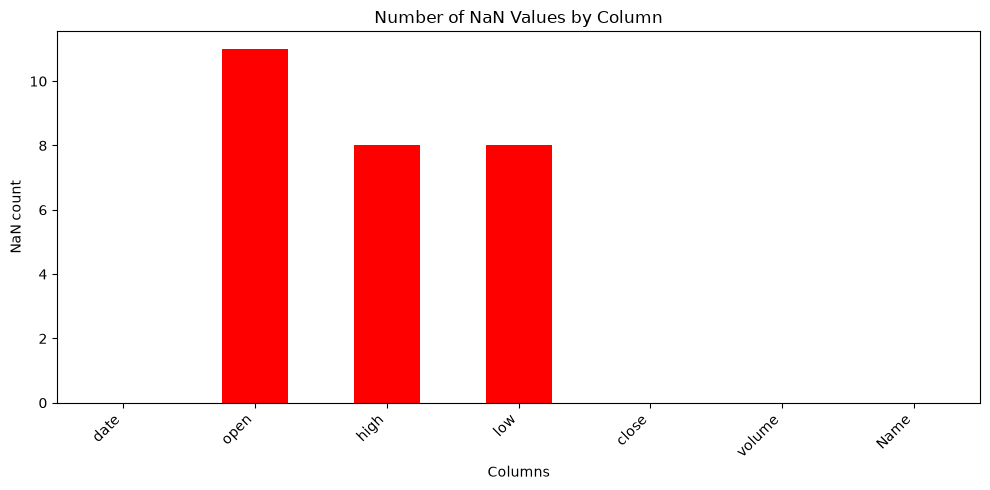

date      0.000000
open      0.001777
high      0.001292
low       0.001292
close     0.000000
volume    0.000000
Name      0.000000
dtype: float64


In [ ]:
# NaN values for each column
nan_counts = df.isna().sum()

nan_counts.plot(
    kind="bar",
    figsize=(10, 5),
    color="red"
)

plt.title("Number of NaN Values by Column")
plt.xlabel("Columns")
plt.ylabel("NaN count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
print(df.isna().mean()*100)

In [61]:
# drop nan values since they are very small fraction
df.dropna(inplace = True)
print(df.isna().mean()*100)

date      0.0
open      0.0
high      0.0
low       0.0
close     0.0
volume    0.0
Name      0.0
dtype: float64


# S&P 500 Stock Data EDA

## 1. Load data
## 2. Basic inspection
## 3. Choose one stock
## 4. Statistics
## 5. Distribution plot
## 6. Line plot over time
## 7. Short interpretation

In [ ]:
# Handling the date column:
df["date"].sort_values(ascending= False).value_counts()

date
2018-02-07    505
2018-02-06    505
2018-02-05    505
2018-02-02    505
2018-02-01    505
             ... 
2013-02-13    476
2013-02-12    476
2013-02-11    476
2013-02-08    476
2013-04-26    472
Name: count, Length: 1259, dtype: int64

In [ ]:
df["date"] = pd.to_datetime(df["date"], format = "%Y-%m-%d")
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_name"] = df["date"].dt.day_name()
df.head()

,date,open,high,low,close,volume,Name,year,month,day,day_name
0,2013-02-08,15.07,15.12,14.63,14.75,8407500,AAL,2013,2,8,Friday
1,2013-02-11,14.89,15.01,14.26,14.46,8882000,AAL,2013,2,11,Monday
2,2013-02-12,14.45,14.51,14.10,14.27,8126000,AAL,2013,2,12,Tuesday
3,2013-02-13,14.30,14.94,14.25,14.66,10259500,AAL,2013,2,13,Wednesday
4,2013-02-14,14.94,14.96,13.16,13.99,31879900,AAL,2013,2,14,Thursday


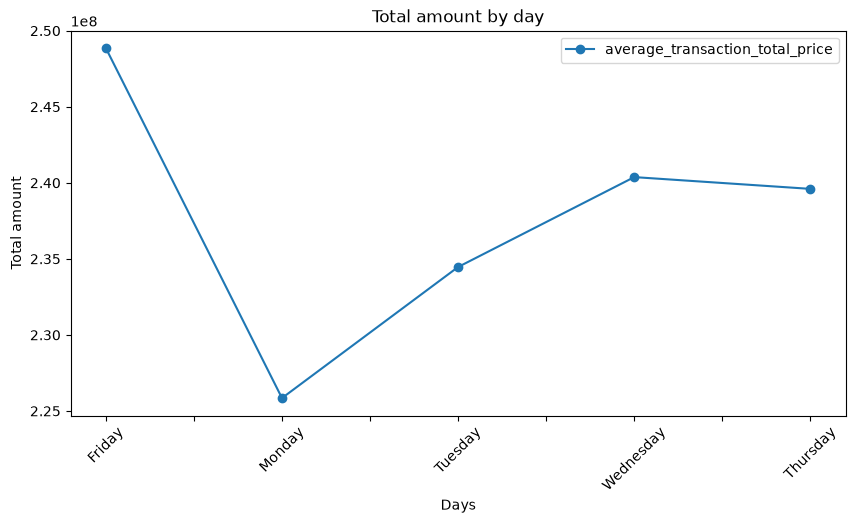

In [95]:
# Find average transaction amount by
day_order = ["Friday", "Monday", "Tuesday", "Wednesday", "Thursday" ]

df_average = df["day_name"].to_frame()

df_average["average_price"] = df[["open", "high", "low", "close"]].mean(axis=1)
df_average["average_transaction_total_price"] = df["volume"] * df_average["average_price"]

daily_volume = (df_average
                .groupby("day_name")["average_transaction_total_price"]
                .mean()
                .reset_index())

daily_volume["day_name"] = pd.Categorical(
    daily_volume["day_name"],
    categories= day_order,
    ordered=True
)
daily_volume.sort_values(by = "day_name", inplace=True )

daily_volume.plot(
    kind = "line",
    figsize= (10,5),
    x="day_name",
    y = "average_transaction_total_price",
    marker ="o"
)

plt.title("Total amount by day")
plt.xlabel("Days")
plt.ylabel("Total amount")
plt.xticks(rotation=45)

plt.show()

In [ ]:
## Choose stock
df["Name"].value_counts().sort_values(ascending=False)

Name
AAL     1259
AAPL    1259
AAP     1259
ABBV    1259
ABC     1259
        ... 
DXC      215
BHGE     152
BHF      142
DWDP     109
APTV      44
Name: count, Length: 505, dtype: int64

In [104]:
df["Name"].nunique()

505

In [106]:
stock_name = "AAPL"
stock_df = df[df["Name"] == stock_name].copy()
stock_df.head()

,date,open,high,low,close,volume,Name,year,month,day,day_name
1259,2013-02-08,67.7142,68.4014,66.8928,67.8542,158168416,AAPL,2013,2,8,Friday
1260,2013-02-11,68.0714,69.2771,67.6071,68.5614,129029425,AAPL,2013,2,11,Monday
1261,2013-02-12,68.5014,68.9114,66.8205,66.8428,151829363,AAPL,2013,2,12,Tuesday
1262,2013-02-13,66.7442,67.6628,66.1742,66.7156,118721995,AAPL,2013,2,13,Wednesday
1263,2013-02-14,66.3599,67.3771,66.2885,66.6556,88809154,AAPL,2013,2,14,Thursday


In [107]:
close_stats = stock_df["close"].agg(["mean", "min", "max",  "std", "median"])
close_stats

mean      109.066698
min        55.789900
max       179.260000
std        30.556812
median    109.010000
Name: close, dtype: float64

In [109]:
# Quartiles:
q1 = stock_df["close"].quantile(0.25)
q3 = stock_df["close"].quantile(0.75)
iqr = q3 - q1
print("Q1: ", q1)
print("Q3: ", q3)
print("IQR: ", iqr)

Q1:  84.83064999999999
Q3:  127.12
IQR:  42.28935000000001


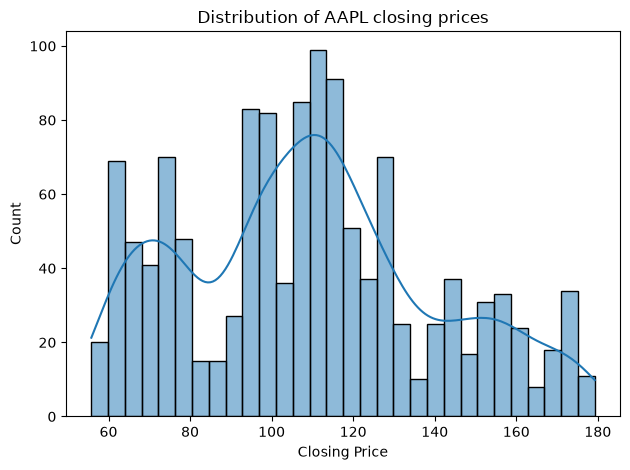

In [ ]:
sns.histplot(data=stock_df, x ="close", bins = 30, kde=True)
plt.title("Distribution of AAPL closing prices")
plt.xlabel("Closing Price")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

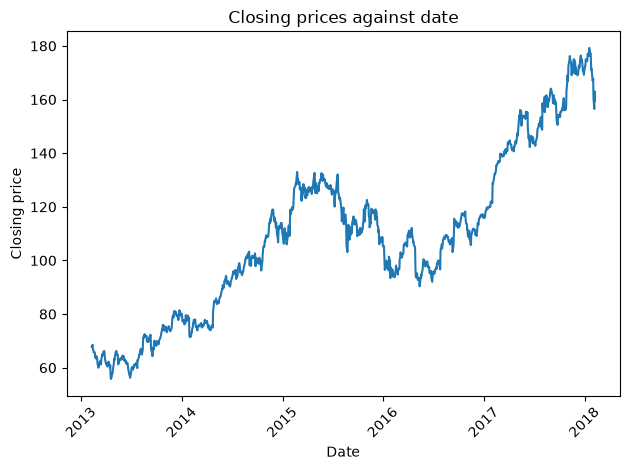

In [121]:
sns.lineplot(data=stock_df, x = "date", y="close")
plt.title("Closing prices against date")
plt.xlabel("Date")
plt.ylabel("Closing price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

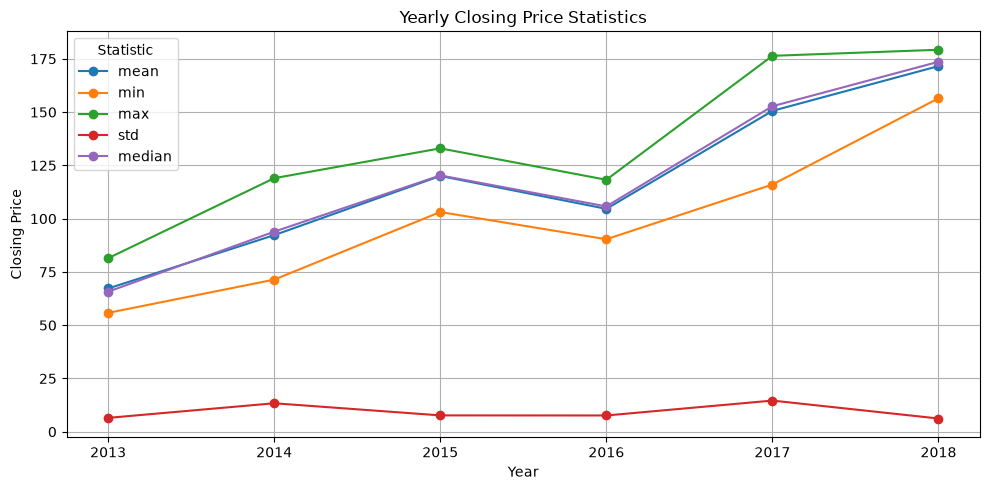

In [ ]:
# closing stats for each year
each_year_close_stats = stock_df.groupby("year")["close"].agg(["mean", "min", "max",  "std", "median"])
each_year_close_stats

each_year_close_stats.plot(
    kind="line",
    figsize=(10, 5),
    marker="o"
)

plt.title("Yearly Closing Price Statistics")
plt.xlabel("Year")
plt.ylabel("Closing Price")
plt.grid(True)
plt.legend(title="Statistic")
plt.tight_layout()
plt.show()